<a href="https://colab.research.google.com/github/sanmita13742/flam_assessment/blob/main/flam_assessment_sanmita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import functions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load and plot data

In [ ]:
df = pd.read_csv("xy_data.csv")

In [ ]:
x_true = df["x"].values
y_true = df["y"].values

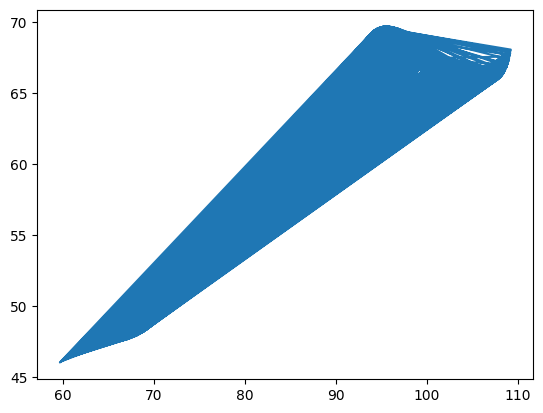

In [ ]:
plt.plot(
    x_true,
    y_true,
    label='Curve'
)

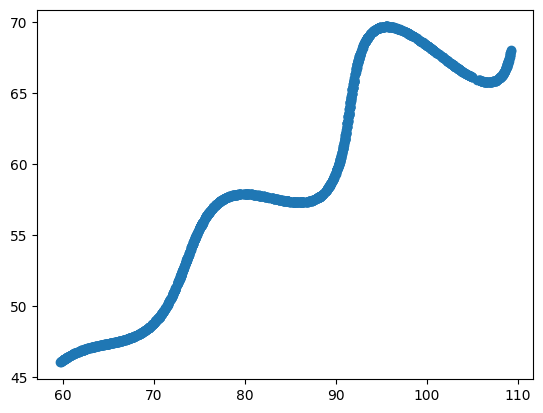

In [ ]:
plt.scatter(
    x_true,
    y_true,
    label='Curve'
)

#Initial parameter estimation using desmos
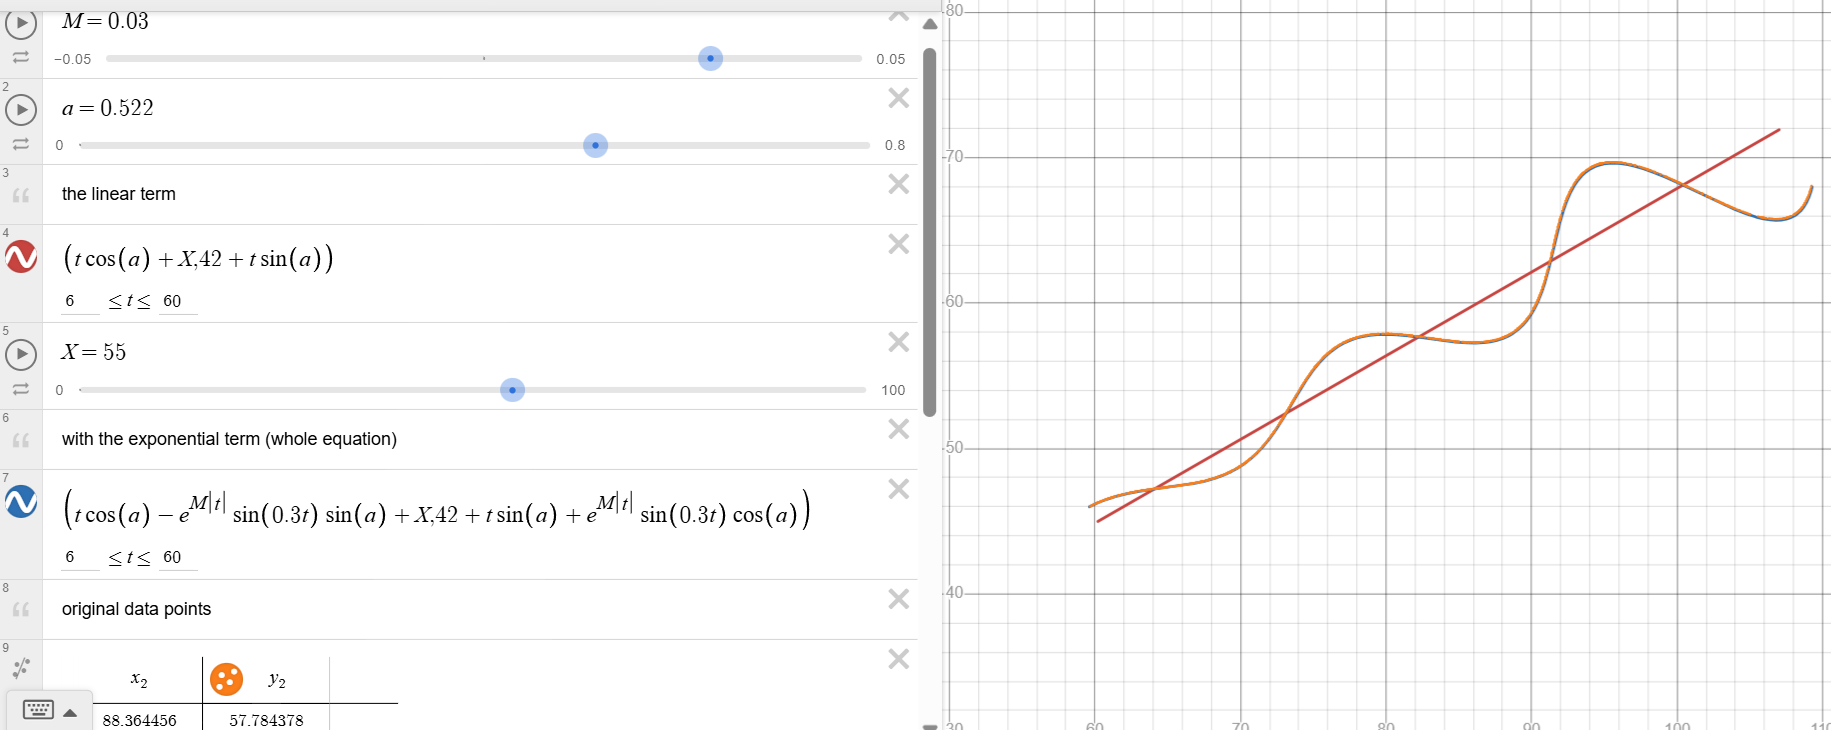

In [ ]:
theta = 0.522
M = 0.03
X = 55

In [ ]:
t = np.linspace(6,60,len(df))

In [ ]:
def curve(M,theta,X,t):
    exp_term = np.exp(M * np.abs(t))
    sin_term = np.sin(0.3 * t)
    x_pred = (
        t*np.cos(theta)
        - exp_term*sin_term*np.sin(theta)
        + X
    )

    y_pred = (
        42
        + t*np.sin(theta)
        + exp_term*sin_term*np.cos(theta)
    )
    return x_pred,y_pred
x_pred,y_pred = curve(M,theta,X,t)

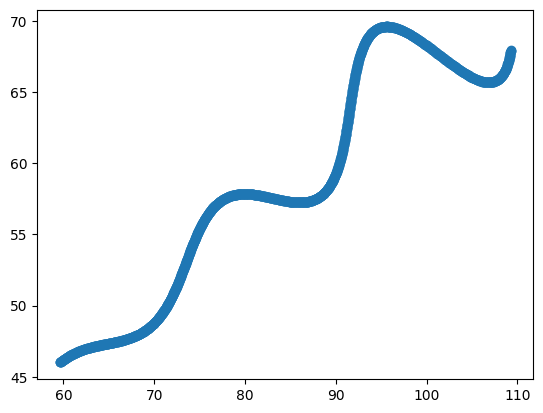

In [ ]:
plt.scatter(
    x_pred,
    y_pred,
    label='Curve'
)

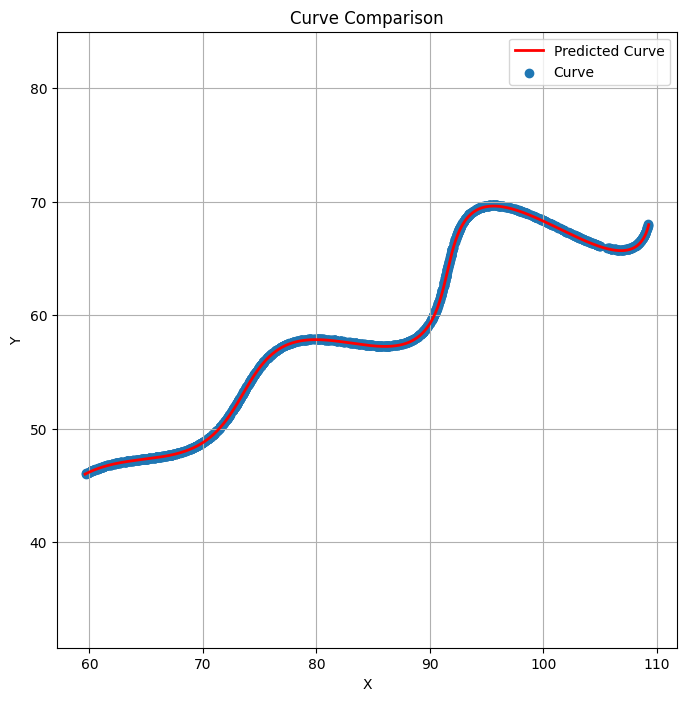

In [ ]:
plt.figure(figsize=(8,8))


plt.plot(
    x_pred,
    y_pred,
    'r',
    linewidth=2,
    label='Predicted Curve'
)
plt.scatter(
    x_true,
    y_true,
    label='Curve'
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Curve Comparison")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# L1 computation

In [ ]:
def l1_distance(x_true, y_true, x_pred, y_pred):
    return np.mean(
        np.abs(x_true - x_pred) +
        np.abs(y_true - y_pred)
    )

In [ ]:
loss = l1_distance(
    x_true,
    y_true,
    x_pred,
    y_pred
)

print(loss)

25.30520518971025


#### the loss is high because the points are unordered
x is approximately an increasing function of t, so sorting the data by x value approximately sorts it by t

In [ ]:
df = df.sort_values("x").reset_index(drop=True)

In [ ]:
x_true = df["x"].values
y_true = df["y"].values
x_pred_n,y_pred_n =curve(M,theta,X,t)

In [ ]:
loss = l1_distance(
    x_true,
    y_true,
    x_pred,
    y_pred
)

print(loss)

0.32704699401586934


Grid search -coarse search, since only around 1.5k values are there, this is my brute force

In [ ]:
from itertools import product

In [ ]:
theta_values = np.arange(0, 50.1, 1)      # 1 degree
M_values = np.arange(-0.05, 0.051, 0.005)
X_values = np.arange(0, 100.1, 1)
theta_values = np.deg2rad(theta_values)
best_loss = np.inf
best_params = None

total = len(theta_values) * len(M_values) * len(X_values)
count = 0

for theta, M, X in product(theta_values, M_values, X_values):

    x_pred, y_pred = curve(M,theta, X,t)

    loss = l1_distance(x_pred, y_pred,
                   x_true, y_true)

    if loss < best_loss:
        best_loss = loss
        best_params = (theta, M, X)

    count += 1

    if count % 10000 == 0:
        print(f"{count}/{total}")


print(f"Theta : {np.rad2deg(best_params[0]):.3f} degrees")
print(f"M     : {best_params[1]:.6f}")
print(f"X     : {best_params[2]:.3f}")
print(f"L1 Loss : {best_loss:.6f}")

10000/108171
20000/108171
30000/108171
40000/108171
50000/108171
60000/108171
70000/108171
80000/108171
90000/108171
100000/108171
Theta : 30.000 degrees
M     : 0.030000
X     : 55.000
L1 Loss : 0.304697


possible reasons for errors
parametric error, t-labeling error